## Probability that a Uniformly-Chosen DFA is Synchronizing

A **uniformly-chosen** DFA with $n$ states over an alphabet $\Sigma$ of size $k$ is one where each transition $\delta(q, a)$ is drawn independently and uniformly at random from $Q$.

We estimate the probability
$$P_k(n) = \mathbb{P}[\text{random DFA with } n \text{ states, } |\Sigma|=k \text{ is synchronizing}]$$
by random (probably Monte Carlo) sampling: for each $(n, k)$ pair we sample $M$ random DFAs and record the fraction that are synchronizing.

**Known theoretical result:** For any fixed $k \geq 2$, $P_k(n) \to 1$ as $n \to \infty$  almost all large DFAs are synchronizing. Larger alphabets accelerate convergence.

We also plot 95% Binomial confidence intervals to quantify estimation uncertainty.

In [3]:
# Part C - Pair graph

def synchronizing_pair_graph(A):
    
    Q = A["Q"]
    Sigma = A["Sigma"]
    tau = A["tau"]
    qs = A["q_s"]
    F = A["F"]

    # Each pair is stored as a frozenset so {q1,q2} == {q2,q1}
    # {q,q} then automatically becomes a singleton

    all_pairs = set()
    for q1 in Q:
        for q2 in Q:
            all_pairs.add(frozenset({q1, q2}))

    singletons = set()
    for node in all_pairs:
        if len(node) == 1:
            singletons.add(node)

    # For each pair and each letter find the image
    # Store the reverse: result <-- pair

    reverse_edges = {node: set() for node in all_pairs}
    for node in all_pairs:
        node_list = list(node)
        if len(node_list) == 1:
            q1, q2 = node_list[0], node_list[0]
        else:
            q1, q2 = node_list[0], node_list[1]

        for a in Sigma:
            # FIX: your tau is stored as tau[a][state]
            target = frozenset({tau[a][q1], tau[a][q2]})
            reverse_edges[target].add(node)

    # Flood backwards from singletons merging pairs

    visited = set(singletons)
    queue = list(singletons)

    while queue:
        current = queue.pop(0)
        for neighbour in reverse_edges[current]:
            if neighbour not in visited:
                visited.add(neighbour)
                queue.append(neighbour)

    # Check every non-singleton pair was reached
    # If so, every pair can be merged and a reset word exists

    non_singletons = all_pairs - singletons

    return non_singletons.issubset(visited)



True


In [2]:
import random

def random_dfa(n, k):  # uniformly chosen DFA
    
    Q = set(range(n))
    Sigma = list(range(k))
    
    # tau[a] is a tuple of length n; tau[a][q] = delta(q, a)
    tau = {a: tuple(random.randint(0, n - 1) for _ in range(n)) for a in Sigma}
    
    return {"Q": Q, "Sigma": Sigma, "tau": tau, "q_s": 0, "F": set()}

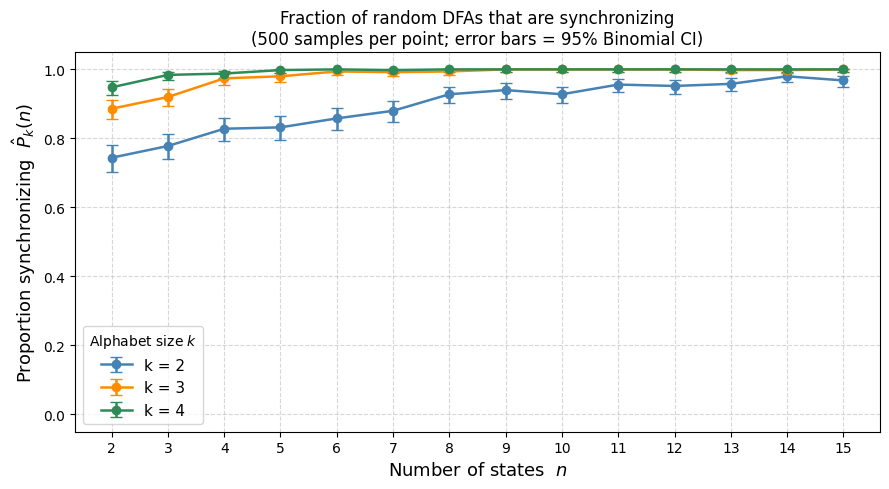

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist

def confidence_interval(successes, trials, alpha=0.05):
    """Return (lower, upper) 95% binomial confidence interval."""
    lo = beta_dist.ppf(alpha / 2,     successes,         trials - successes + 1)
    hi = beta_dist.ppf(1 - alpha / 2, successes + 1,     trials - successes)
    lo = 0.0 if np.isnan(lo) else lo
    hi = 1.0 if np.isnan(hi) else hi
    return lo, hi


state_counts = list(range(2, 16))   # n = 2, 3, ..., 15
alphabet_sizes = [2, 3, 4]          # k values to compare
M = 500                             # DFAs sampled per (n, k) pair

random.seed(42)
results = {}   # results[(k, n)] = (proportion, lo, hi)

for k in alphabet_sizes:                             # check if dfa is synchronizing over parameter space
    for n in state_counts:
        sync_count = sum(
            synchronizing_pair_graph(random_dfa(n, k))
            for _ in range(M)
        )
        p_hat = sync_count / M
        lo, hi = confidence_interval(sync_count, M)
        results[(k, n)] = (p_hat, lo, hi)

# plot 
fig, ax = plt.subplots(figsize=(9, 5))
colors = {2: "steelblue", 3: "darkorange", 4: "seagreen"}

for k in alphabet_sizes:
    ns      = state_counts
    p_hats  = [results[(k, n)][0] for n in ns]
    lowers  = [results[(k, n)][1] for n in ns]
    uppers  = [results[(k, n)][2] for n in ns]
    errs    = [
        [p - lo for p, lo in zip(p_hats, lowers)],
        [hi - p for p, hi in zip(p_hats, uppers)],
    ]
    ax.errorbar(ns, p_hats, yerr=errs,
                marker="o", capsize=4, label=f"k = {k}",
                color=colors[k], linewidth=1.8)

ax.set_xlabel("Number of states  $n$", fontsize=13)
ax.set_ylabel("Proportion synchronizing  $\\hat{P}_k(n)$", fontsize=13)
ax.set_title(f"Fraction of random DFAs that are synchronizing\n"
            f"({M} samples per point; error bars = 95% Binomial CI)",
            fontsize=12)
ax.legend(title="Alphabet size $k$", fontsize=11)
ax.set_ylim(-0.05, 1.05)
ax.set_xticks(state_counts)
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()